# Minimal Scaling Laws

This is a minimal example of Chinchilla scaling laws ([Deepmind, 2022](https://arxiv.org/pdf/2203.15556)) in a single Colab notebook.

This notebook trains GPT-style transformers of up to 10M parameters on synthetic datasets of integer addition. From the relationship between dataset size, model size, and loss, we can establish scaling laws that predict the optimal performance of much larger language models.

This idea was taken from Vlad Feinberg's [blog post](https://vladfeinberg.com/2026/05/10/how-to-land-a-job-at-a-frontier-lab.html):


> *Code a ~10M transformer using only jax, flax, optax in free colab using tpu.
Hard code it to accept digits 0-9, space, +, =.
Generate a dataset of simple up-to-3-digit numbers, have it learn addition.
Should train quickly on T4 GPU (pad examples to fixed length).
Derive Chinchilla laws for this; see how they differ for dense vs MoE architectures.*



In [1]:
import numpy as np
import pickle
import os
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

from flax.training import train_state
from google.colab import drive
from matplotlib import pyplot as plt
from matplotlib import cm, colors

## Data

We use a simple synthetic dataset of integer addition examples. Each training example is a string representing two random integers, each up to `MAX_DIGITS` in length, being added together: e.g. `142+17=159`. This can be represented with a vocabulary of only 14 tokens: 10 tokens for digits plus a few operator and padding tokens. We use a simple character-level tokenizer.

While Vlad suggests training with 3-digits operands, this saturates very quickly even on small models. Bumping `MAX_DIGITS` to 5 or 6 (or higher) will give more useful results if you intend on training models up to ~10M params. Naturally this will also increase the training time.

### Tokenization

In [2]:
MAX_DIGITS = 6  # Operand length

TRAIN_SEED = 0
EVAL_SEED = 12

ZFILL = False  # If True, adds leading zeros to pad each operand to MAX_DIGITS (e.g. 1+11=12 -> 001+011=012).

PAD_TOKEN = "_"
VOCAB = [str(x) for x in range(10)] + ["+", "=", " ", PAD_TOKEN]
VOCAB_SIZE = len(VOCAB)
print(f"Vocab: {VOCAB}, with {VOCAB_SIZE} unique tokens.")

stoi = {s: idx for idx, s in enumerate(VOCAB)}
itos = {idx: s for idx, s in enumerate(VOCAB)}
PAD_ID = stoi[PAD_TOKEN]

ANSWER_DIGITS = MAX_DIGITS+1
MAX_LEN = 2*MAX_DIGITS + 2 + ANSWER_DIGITS
SEQUENCE_LEN = MAX_LEN - 1  # Used to size positional embeddings and pad sequences at inference time.

Vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=', ' ', '_'], with 14 unique tokens.


### Dataset Generation

In [3]:
def generate_example(a: int, b: int, zfill: bool = ZFILL):
    """
    Generates an addition training example for integers a and b.

    Args:
      a, b  : int -- integer values to be added
      zfill : bool -- if True, pad operands with leading zeros up to MAX_DIGITS

    Returns:
      tokens  : list[int] -- token list of MAX_LEN
      mask    : list[int] -- binary mask for tokens, 1 on answer tokens
    """
    if zfill:
        a_str = str(a).zfill(MAX_DIGITS)
        b_str = str(b).zfill(MAX_DIGITS)
        ans = str(a + b).zfill(ANSWER_DIGITS)
    else:
        a_str, b_str = str(a), str(b)
        ans = str(a + b)
    prompt = f"{a_str}+{b_str}="
    example = prompt + ans
    pad_len = MAX_LEN - len(example)
    example += PAD_TOKEN * pad_len
    mask = [0] * len(prompt) + [1] * len(ans) + [0] * pad_len
    tokens = [stoi[c] for c in example]
    return tokens[:MAX_LEN], mask[:MAX_LEN]  # Cutoff example at max sequence length

def make_batch(n: int, rng):
    """
    Generates a batch of n examples of addition.

    Args:
      n   : int -- batch size
      rng : np.Generator -- numpy pseudorandom number generator

    Returns:
      x     : jnp int32 array (n, MAX_LEN) -- token ids.
      mask  : jnp int32 array (n, MAX_LEN) -- answer mask.
    """
    max_val = 10 ** MAX_DIGITS
    A = rng.integers(0, max_val, size=n)
    B = rng.integers(0, max_val, size=n)
    x = np.zeros((n, MAX_LEN), dtype=np.int32)
    mask = np.zeros((n, MAX_LEN), dtype=np.int32)
    for i, (a, b) in enumerate(zip(A, B)):
        x[i], mask[i] = generate_example(a, b)
    return jnp.asarray(x), jnp.asarray(mask)

In [4]:
# Inspect data
_x, _mask = make_batch(4, np.random.default_rng(0))
for i in range(4):
    print("".join(itos[int(t)] for t in _x[i]), _mask[i])

850624+307829=1158453 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
636961+40973=677934__ [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0]
511136+75240=586376__ [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0]
269786+16527=286313__ [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0]


## Models

We use a GPT-style pre-norm decoder-only dense transformer with GeLU activations. The hidden dimension is always set at 4 times the model (bottleneck) dimension. Smaller models have a single attention head per layer, while larger models have `d_model // 32` attention heads.  We scale the parameter count from ~1k to ~10M by simultaneously increasing the depth (layers) and the model dimension.

In [5]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention."""

    d_model: int
    n_heads: int

    @nn.compact
    def __call__(self, x):
        B, T, C = x.shape
        d_head = self.d_model // self.n_heads
        qkv = nn.Dense(3 * self.d_model, use_bias=False, name="qkv")(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)

        def heads(t):
            return t.reshape(B, T, self.n_heads, d_head).transpose(0, 2, 1, 3)  # (B,T,C) -> (B,n_heads,T,d_head)

        q, k, v = map(heads, (q, k, v))
        att = (q @ k.transpose(0, 1, 3, 2)) / jnp.sqrt(d_head)  # (B,n_heads,T,T)
        causal = jnp.tril(jnp.ones((T, T), dtype=bool))
        att = jnp.where(causal, att, -1e9)
        att = jax.nn.softmax(att, axis=-1)
        out = (att @ v).transpose(0, 2, 1, 3).reshape(B, T, C)
        return nn.Dense(self.d_model, use_bias=False, name="proj")(out)

class Block(nn.Module):
    """A pre-norm transformer block: x = x + sublayer(LayerNorm(x))."""

    d_model: int
    n_heads: int
    d_hidden: int

    @nn.compact
    def __call__(self, x):
        x = x + CausalSelfAttention(self.d_model, self.n_heads)(nn.LayerNorm()(x))
        h = nn.gelu(nn.Dense(self.d_hidden)(nn.LayerNorm()(x)))
        h = nn.Dense(self.d_model)(h)
        return x + h


class GPT(nn.Module):
    """Decoder-only Transformer class."""
    vocab_size: int
    d_model: int
    n_heads: int
    n_layers: int
    d_hidden: int
    max_len: int

    @nn.compact
    def __call__(self, idx):
        B, T = idx.shape  # idx: (B, T)
        tok = nn.Embed(self.vocab_size, self.d_model, name="tok_emb")(idx)
        pos = nn.Embed(self.max_len, self.d_model, name="pos_emb")(jnp.arange(T))
        x = tok + pos[None, :, :]
        for i in range(self.n_layers):
            x = Block(self.d_model, self.n_heads, self.d_hidden, name=f"block_{i}")(x)
        x = nn.LayerNorm()(x)
        return nn.Dense(self.vocab_size, use_bias=False, name="head")(x)  # logits

def build_model(d_model, n_layers):
    """Constructs a decoder-only transformer. Set n_heads = max(1, d_model // 32) and d_hidden = 4 * d_model"""
    n_heads = max(1, d_model // 32)
    assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
    return GPT(vocab_size=VOCAB_SIZE, d_model=d_model, n_heads=n_heads, n_layers=n_layers, d_hidden=4 * d_model, max_len=SEQUENCE_LEN)

def count_params(params):
    """Returns the total number of parameters in a model's Flax param pytree."""
    return sum(x.size for x in jax.tree_util.tree_leaves(params))

## Training

We try to match the Chinchilla methodology by using the AdamW and a cosine lr scheduler that bottoms out at 10% of `peak_lr` after exactly `total_steps`. Because the schedule is tied to a fixed step count, multiple runs of varying length are needed for each model.

In [6]:
@jax.jit
def train_step(state, x, mask):
    """Applies a single training step to the model state."""
    def loss_fn(params):
        """Cross-entropy loss."""
        logits = state.apply_fn({"params": params}, x[:, :-1])
        ce = optax.softmax_cross_entropy_with_integer_labels(logits, x[:, 1:])
        answer_mask = mask[:, 1:].astype(jnp.float32)
        return (ce * answer_mask).sum() / answer_mask.sum()

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    return state.apply_gradients(grads=grads), loss

@jax.jit
def eval_loss(state, x, mask):
    logits = state.apply_fn({"params": state.params}, x[:, :-1])
    ce = optax.softmax_cross_entropy_with_integer_labels(logits, x[:, 1:])
    answer_mask = mask[:, 1:].astype(jnp.float32)
    return (ce * answer_mask).sum() / answer_mask.sum()

def make_train_state(model, total_steps, peak_lr=1e-3, warmup_steps=None, end_lr_frac=0.1, weight_decay=0.01, seed=TRAIN_SEED):
    """Creates the model train state using AdamW optimizer with a warmup and cosine schedule that bottoms out at `total_steps`, matching Chinchilla paper methodology."""
    if warmup_steps is None:
        warmup_steps = min(200, max(1, total_steps // 20))
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=peak_lr,
        warmup_steps=warmup_steps,
        decay_steps=total_steps,
        end_value=peak_lr * end_lr_frac,  # decays to 10% of peak_lr, as in the Chinchilla paper
    )
    params = model.init(jax.random.PRNGKey(seed), jnp.zeros((1, SEQUENCE_LEN), jnp.int32))["params"]
    tx = optax.chain(optax.clip_by_global_norm(1.0), optax.adamw(schedule, weight_decay=weight_decay))
    return train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

In [7]:
def _prompt_ids(a, b):
    """Token ids for the "a+b=" prompt, respecting ZFILL (matches training format)."""
    if ZFILL:
        s = f"{str(a).zfill(MAX_DIGITS)}+{str(b).zfill(MAX_DIGITS)}="
    else:
        s = f"{a}+{b}="
    return [stoi[c] for c in s]

def predict_sum(state, a, b):
    """
    Greedily decode the model's answer for a + b.

    Args:
      state : TrainState -- trained model state to decode from
      a, b  : int -- integer operands to add

    Returns:
      answer : str -- decoded answer as a normal integer string (e.g. "15", leading zeros stripped)
    """
    prompt = _prompt_ids(a, b)
    seq = list(prompt)
    for _ in range(ANSWER_DIGITS):
        x = np.full((1, SEQUENCE_LEN), PAD_ID, dtype=np.int32)
        x[0, :len(seq)] = seq
        logits = state.apply_fn({"params": state.params}, jnp.asarray(x))
        seq.append(int(jnp.argmax(logits[0, len(seq) - 1])))
    digits = "".join(itos[t] for t in seq[len(prompt):])
    return str(int(digits)) if digits.isdigit() else digits

@jax.jit
def _batch_logits(state, x):
    """Forward pass over a whole batch."""
    return state.apply_fn({"params": state.params}, x)

def accuracy(state, rng, n=500):
    """
    Computes exact-match accuracy over n random addition problems, in parallel.

    Args:
      state : TrainState -- trained model state to evaluate
      rng   : np.Generator -- numpy pseudorandom number generator
      n     : int -- number addition problems to evaluate

    Returns:
      acc : float -- fraction of the n problems answered exactly correctly (0..1)
    """
    hi = 10 ** MAX_DIGITS
    a = rng.integers(0, hi, size=n)
    b = rng.integers(0, hi, size=n)

    prompts = [_prompt_ids(a[i], b[i]) for i in range(n)]
    plen = np.array([len(p) for p in prompts], dtype=np.int32)   # per-example prompt length

    seqs = np.full((n, SEQUENCE_LEN), PAD_ID, dtype=np.int32)
    for i, p in enumerate(prompts):
        seqs[i, :len(p)] = p
    seqs = jnp.asarray(seqs)

    rows = np.arange(n)
    gen = []
    for i in range(ANSWER_DIGITS):
        logits = _batch_logits(state, seqs)  # (n, SEQUENCE_LEN, V)
        read = np.minimum(plen + i - 1, SEQUENCE_LEN - 1)
        nxt = jnp.argmax(logits[rows, read, :], axis=-1)
        gen.append(nxt)
        write = plen + i
        feed = rows[write < SEQUENCE_LEN]
        if feed.size:
            seqs = seqs.at[feed, write[feed]].set(nxt[feed])
    gen = np.asarray(jnp.stack(gen, axis=1))

    place = 10 ** np.arange(ANSWER_DIGITS - 1, -1, -1)
    pred = (gen * place).sum(axis=1)
    valid = (gen <= 9).all(axis=1)
    return float((valid & (pred == a + b)).mean())

## Scaling Laws

We scale models from ~1k to ~10M parameters and scale FLOPs up to ~10e16 (for 6 digit addition).

TODO: Discuss model ladder

Because the data is synthetically generated, we know that the exact number of pretraining tokens for a model are `steps * batch_size * MAX_LEN`.

As a useful approximation, `FLOPS ≈ 6 * params * tokens`, with `2 * params * tokens` for the forward pass and `4 * params * tokens` for backpropagation.

In [8]:
def _load(path):
    drive.mount("/content/drive")
    if path and os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    return []

def _key(r):
    """Identity of a run for skip-on-resume."""
    return (r["d_model"], r["n_layers"], r["cycle_steps"], r.get("seed", 0))

def train_run(d_model, n_layers, steps, batch=512, peak_lr=1e-3, seed=0, log_every=50):
    """
    Trains one model for steps and logs smoothed training loss vs FLOPs.

    Args:
      d_model   : int -- model (bottleneck) dimension
      n_layers  : int -- number of transformer blocks
      steps     : int -- number of training steps to run
      batch     : int -- batch size per step
      peak_lr   : float -- peak learning rate for the warmup/cosine schedule
      seed      : int -- seed for parameter init and batch sampling
      log_every : int -- log the smoothed loss and FLOPs every this many steps

    Returns:
      run : dict -- the run's trajectory with keys N (param count), d_model,
                    n_layers, cycle_steps (== steps), flops (list[float]) and
                    loss (list[float], EMA-smoothed) logged at each checkpoint
    """
    model = build_model(d_model, n_layers)
    state = make_train_state(model, total_steps=steps, peak_lr=peak_lr, seed=seed)
    N = count_params(state.params)
    tok_per_step = batch * SEQUENCE_LEN
    rng = np.random.default_rng(seed)

    ema, flops, loss = None, [], []
    for step in range(1, steps + 1):
        X, F = make_batch(batch, rng)
        state, l = train_step(state, X, F)
        ema = float(l) if ema is None else 0.98 * ema + 0.02 * float(l)  # exponential moving average (EMA) smoothing
        if step % log_every == 0 or step == steps:
            flops.append(6.0 * N * step * tok_per_step)
            loss.append(ema)
    return dict(N=N, d_model=d_model, n_layers=n_layers, cycle_steps=steps, flops=flops, loss=loss)


def run_sweep(steps_list, ladder, batch=512, peak_lr=1e-3, seed=TRAIN_SEED):
    """
    Trains models in a sweep of ladder x steps_list, logging each full trajectory.

    Saves logs to Google Drive and skips runs already present (resume-safe).

    Args:
      steps_list  : list[int] -- training step counts to run per model
      ladder      : list[tuple[int, int]] -- model hyperparams (d_model, n_layers)
      batch       : int -- batch size per step
      peak_lr     : float -- peak learning rate for each run
      seed        : int -- seed passed to each run and used in the resume key

    Returns:
      runs : list[dict] -- all run trajectories (see train_run)
    """
    path = f"/content/drive/MyDrive/Colab Notebooks/chinchilla_{MAX_DIGITS}_digit_runs.pkl"
    runs = _load(path)
    done = {_key(r) for r in runs}
    total = len(ladder) * len(steps_list)
    print(f"{len(done)} runs already present in {path}\n")

    for d_model, n_layers in ladder:
        for steps in steps_list:
            if (d_model, n_layers, steps, seed) in done:
                continue
            r = train_run(d_model, n_layers, steps, batch, peak_lr, seed)
            r["seed"] = seed
            runs.append(r)
            with open(path, "wb") as f:
                pickle.dump(runs, f)
            print(f"[{len(runs):>2}/{total}] d = {d_model:3d} N = {r['N']:>9,} steps = {steps:>6} loss = {r['loss'][-1]:.4f}  (saved)")
    return runs

In [ ]:
"""
Model ladder from ~1k to ~10M.

Total model params ~= 12 * n_layers * d_model^2.

d_head is fixed at min(32, d_model), and d_hidden = 4 * d_model.
Each attention block has ~4 * d_model^2 params. ()
Each MLP block has ~2 * 4 * d_model^2 params. (up/down * d_hidden)
Per-layer params = (attention + MLP) ~= 12 * d_model^2.
"""
MODEL_LADDER = [
    # (d_model, n_layers), total params
    (8,  1),    # ~1K
    (16, 1),    # ~4K
    (16, 2),    # ~7K
    (24, 2),    # ~15K
    (32,  2),   # ~25K
    (32,  3),   # ~37k
    (48,  3),   # ~83K
    (64,  3),   # ~150K
    (96,  3),   # ~330K
    (128, 4),   # ~790K
    (160, 5),   # ~1.5M
    (192, 6),   # ~2.7M
    (224, 8),   # ~4.8M
    (256, 12),  # ~9.4M
]

# Run model sweep
STEPS_LIST = (1000, 2000, 4000, 8000, 16000, 32000, 64000)  # Change this to speed up training
BATCH_SIZE = 512
runs = run_sweep(STEPS_LIST, MODEL_LADDER, BATCH_SIZE)

In [9]:
# In subsequent sessions, mount Drive and load runs from the same path
runs = _load(f"/content/drive/MyDrive/Colab Notebooks/chinchilla_{MAX_DIGITS}_digit_runs.pkl")

Mounted at /content/drive


### Fix Model Size and Scale Tokens (Chinchilla Figure 2)

For this experiment, we consider models of increasing size in our model ladder (from 1k to 10M params) and train them on various amounts of tokens.

You might think that we can just do one very long run for each model size. However, the learning rate decay schedule is set over a fixed number of steps, so we have to do multiple runs of the same model size with different steps/data/compute.

In [13]:
def plot_figure2(runs, log_loss=True):
    """Plots Loss vs FLOPs for every run, colored by parameter count (N)."""
    def fmt(n):
        if n >= 1e6:
            return f"{n / 1e6:.1f}M"
        if n >= 1e3:
            return f"{n / 1e3:.0f}K"
        return str(int(n))

    Ns = sorted({r["N"] for r in runs})
    norm = colors.LogNorm(vmin=min(Ns), vmax=max(Ns))
    cmap = cm.plasma

    fig, ax = plt.subplots(figsize=(7, 5))
    for r in runs:
        ax.plot(r["flops"], r["loss"], "-", color=cmap(norm(r["N"])), lw=1, alpha=0.8)

    if log_loss:
        ax.set_yscale("log")
    ax.set_xscale("log"); ax.set_xlabel("FLOPs"); ax.set_ylabel("Training Loss")
    ax.set_title("Figure 2 | Training Curve Envelope")
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Parameters")
    cbar.set_ticks(Ns); cbar.set_ticklabels([fmt(n) for n in Ns]); cbar.minorticks_off()
    plt.tight_layout(); plt.show()


Compare the plot below to Figure 2 in the Chinchilla paper. You'll notice that the loss curves in Chinchilla are much smoother. You'll also notice that the training loss for the addition task approaches 0 with sufficient compute, while the loss for natural language modeling is still `>2` at much higher compute budgets. Some of this is probably related to the much larger vocabulary of the Chinchilla models (`32k` vs `14`). However, much of the difference probably relates to the difference in modeling task difficulty.

You can use this plot to pick an optimal model size for a compute budget. If you want to spend `10e14` FLOPs to train your model on this addition task, find `10e14` on the horizontal axis and draw a vertical line upward. The first loss curve you intersect has the lowest loss and will be from the most compute-optimal model size for that budget.

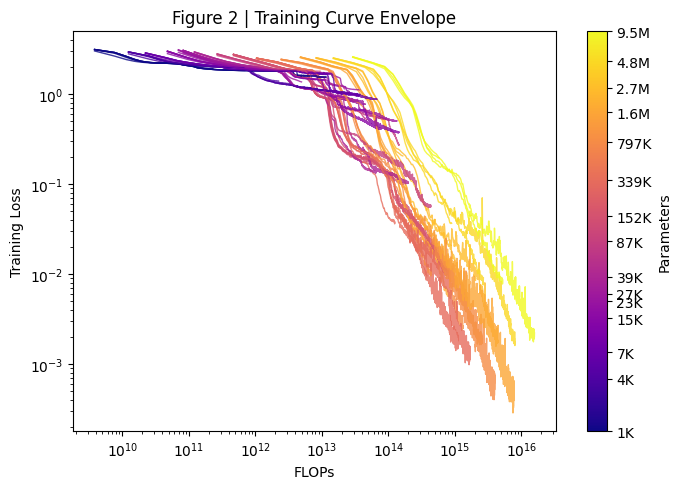

In [14]:
plot_figure2(runs, log_loss=True)

### Set Fixed FLOPs and Vary Model Size (IsoFLOP profiles, Chinchilla Figure 3)

For this experiment, pick fixed compute (FLOP) budgets and train models of different sizes up to the FLOP budget. This allows us to measure the optimal parameter vs data allocation of the compute budget.

In [33]:
def _auto_budgets(runs, k=5, min_sizes=2):
    """Pick k log-spaced FLOP budgets that are covered by >= min_sizes model sizes
    (so each slice actually has enough points to form a U)."""
    allf = np.concatenate([np.asarray(r["flops"]) for r in runs])
    grid = np.logspace(np.log10(allf.min()), np.log10(allf.max()), 60)
    good = [C for C in grid if len({r["N"] for r in runs if r["flops"][0] <= C <= r["flops"][-1]}) >= min_sizes]
    if len(good) <= k:
        return good
    return [good[i] for i in np.linspace(0, len(good) - 1, k).astype(int)]


def isoflop_slices(runs, budgets):
    """
    For each budget C: interpolate each run to its loss at C, then keep the min
    loss per model size (best-annealed reading). Returns {C: [(N, loss), ...]}.

    Args:
      runs     : list -- run dicts with "N", "flops", "loss"
      budgets  : list -- FLOP budgets C to slice at

    Returns:
      slices : dict -- {C: [(N, loss), ...]} sorted by N
    """
    slices = {}
    for C in budgets:
        best = {}
        for r in runs:
            f, l = np.asarray(r["flops"]), np.asarray(r["loss"])
            if C < f[0] or C > f[-1]:
                continue
            loss_C = np.exp(np.interp(np.log(C), np.log(f), np.log(l)))
            best[r["N"]] = min(loss_C, best.get(r["N"], np.inf))
        slices[C] = sorted(best.items())
    return slices

def _parabola_vertex(N, L):
    """
    Fit log10(loss) as a quadratic in log10(N) and return the vertex N (the
    IsoFLOP optimum) plus the fit coefficients.

    Fitting in log-loss keeps the fit well-behaved when losses span orders of
    magnitude, and the fitted curve is always positive. Since log is monotonic,
    the vertex N is the same compute-optimal N as minimizing loss directly.

    Returns:
      (N_opt, coeffs):
        N_opt  : float or None -- parameter count at the parabola vertex, or None
                 if the parabola opens downward or the vertex falls outside the
                 sampled N range
        coeffs : np.ndarray -- [c2, c1, c0] quadratic coefficients for
                 log10(L) as a function of log10(N)
    """
    x = np.log10(N)
    y = np.log10(L)
    coeffs = np.polyfit(x, y, 2)
    c2, c1, _ = coeffs
    if c2 <= 0:  # not convex -> no U-shaped minimum
        return None, coeffs
    x_opt = -c1 / (2 * c2)
    if x_opt < x.min() or x_opt > x.max():  # vertex outside sampled range
        return None, coeffs
    return 10 ** x_opt, coeffs


def plot_isoflop(runs, budgets=None, log_loss=False, show_optimal=False):
    """Plot IsoFLOP curves (one per budget) with the compute-optimal N marked.
    Returns [(C, N_opt), ...] from the parabola-in-log-space vertex of each U."""

    if budgets is None:
        budgets = _auto_budgets(runs)
    slices = isoflop_slices(runs, budgets)

    cmap = plt.cm.viridis_r

    fig, ax = plt.subplots(figsize=(7, 5))
    items = [(C, pts) for C, pts in sorted(slices.items()) if len(pts) >= 3]
    optima = []
    for i, (C, pts) in enumerate(items):
        color = cmap(0.15 + 0.7 * i / max(1, len(items) - 1))
        N = np.array([p[0] for p in pts], float)
        L = np.array([p[1] for p in pts], float)
        ax.plot(N, L, "o", color=color, label=f"{C:.0e}", alpha=0.9)

        N_opt, coeffs = _parabola_vertex(N, L)

        # Dotted fitted parabola (in log-log space) across the sampled N range
        x_fit = np.linspace(np.log10(N).min(), np.log10(N).max(), 200)
        L_fit = 10 ** np.polyval(coeffs, x_fit)
        ax.plot(10 ** x_fit, L_fit, ":", color=color, alpha=0.8, zorder=2)

        if N_opt is not None and show_optimal:
            L_opt = 10 ** np.polyval(coeffs, np.log10(N_opt))
            ax.plot(N_opt, L_opt, "*", color=color, markersize=15,
                    markeredgecolor="k", markeredgewidth=0.5, zorder=5)
            optima.append((C, N_opt))

    if log_loss:
        ax.set_yscale("log")
    ax.set_xscale("log"); ax.set_xlabel("Parameters"); ax.set_ylabel("Training Loss");
    ax.set_title("Figure 3 | IsoFLOP Curves"); ax.legend(title="FLOPs", fontsize=8)
    plt.tight_layout(); plt.show()

    for C, N_opt in optima:
        print(f"C={C:.1e}  N_opt~={N_opt:,.0f}  D_opt~={C / (6 * N_opt):,.0f}")
    return optima

Compare the plot below to Figure 3 in the Chinchilla paper. In that paper, the valleys in the isoFLOP curves are smoother and better-defined. This plot reveals some of the limitations of the synthetic addition task. Because the task is solvable, the loss with larger FLOP budgets approaches zero. Note how the Chinchilla figure uses a linear vertical axis while we need to use a log scale for the training loss to better see the relationships.

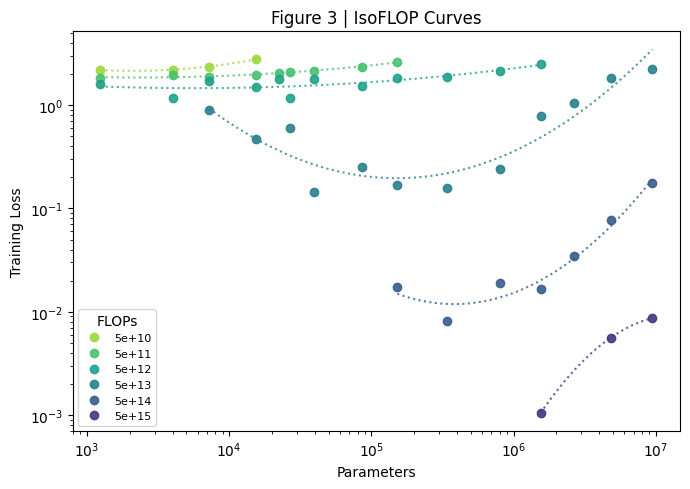

In [34]:
_ = plot_isoflop(runs, log_loss=True, budgets=[5e9, 5e10, 5e11, 5e12, 5e13, 5e14, 5e15, 5e16])

### Derive Scaling Laws

The Chinchilla paper tries 3 approaches for fitting scaling laws:

1. Minimum over training curves
2. IsoFLOP profiles
3. Parametric modeling of loss

In [26]:
"""
Derive Chinchilla-style scaling laws from runs.

  Approach 1/2  -- the compute-optimal FRONTIER (lower-loss envelope of the
                   training curves) gives (C, N_opt, D_opt) samples; fit
                       N_opt = k_N * C^a ,  D_opt = k_D * C^b .
                   Chinchilla: a ~ b ~ 0.5, and a + b = 1 exactly (C = 6 N D).

  Approach 3    -- fit the LOSS SURFACE  L(N, D) = E + A*N^-alpha + B*D^-beta
                   to every logged point, then derive the compute-optimal
                   exponents analytically:  a = beta/(alpha+beta),
                   b = alpha/(alpha+beta).

Each logged point contributes N = r["N"], C = flops, D = C/(6N), L = loss.

Note that addition is solvable, so once L approaches 0 the power-law form breaks.
`loss_floor` drops those points so the fit uses only the sloped regime.
"""

def _points(runs):
    """Every logged step as (C, N, D, L) arrays."""
    C, N, D, L = [], [], [], []
    for r in runs:
        for f, l in zip(r["flops"], r["loss"]):
            C.append(f); N.append(r["N"]); D.append(f / (6 * r["N"])); L.append(l)
    return (np.asarray(C, float), np.asarray(N, float), np.asarray(D, float), np.asarray(L, float))


def frontier(runs, n_bins=25, loss_floor=0.1):
    """
    Extract the compute-optimal frontier (Approach 1): within each log-FLOP bin,
    the min-loss point, keeping only the sloped regime (L > loss_floor).

    Args:
      runs       : list -- run dicts with "N", "flops", "loss"
      n_bins     : int -- number of log-spaced FLOP bins to take the min over
      loss_floor : float -- drop bin winners with loss <= this (saturated regime)

    Returns:
      C : np.ndarray -- FLOPs at each frontier point
      N : np.ndarray -- parameter count at each frontier point
      D : np.ndarray -- tokens (C / 6N) at each frontier point
      L : np.ndarray -- loss at each frontier point
    """
    C, N, D, L = _points(runs)
    edges = np.logspace(np.log10(C.min()), np.log10(C.max()), n_bins + 1)
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (C >= lo) & (C < hi)
        if m.any():
            j = np.argmin(L[m])
            if L[m][j] > loss_floor:
                out.append((C[m][j], N[m][j], D[m][j], L[m][j]))
    if not out:
        raise ValueError(f"No frontier points above loss_floor={loss_floor}; lower it to keep more of the sloped regime.")
    a = np.array(out)
    return a[:, 0], a[:, 1], a[:, 2], a[:, 3]


def _powerlaw(x, y):
    """Fit y = k * x^p in log-log space; return (p, k)."""
    p, logk = np.polyfit(np.log(x), np.log(y), 1)
    return p, np.exp(logk)


# ----------------------------------------------------------------------------
# Approach 3: parametric loss surface.
# ----------------------------------------------------------------------------
def fit_loss_surface(runs, loss_floor=0.1):
    """
    Fit L(N,D) = E + A*N^-alpha + B*D^-beta via robust (Huber) regression on
    log-loss, and derive the implied compute-optimal exponents a, b.

    Args:
      runs       : list -- run dicts with "N", "flops", "loss"
      loss_floor : float -- drop points with loss <= this (saturated regime)

    Returns:
      surf : dict -- fitted constants E, A, B and exponents alpha, beta, plus the
                     implied compute-optimal exponents a = beta/(alpha+beta) and
                     b = alpha/(alpha+beta)
    """
    from scipy.optimize import least_squares
    _, N, D, L = _points(runs)
    keep = L > loss_floor
    logN, logD, logL = np.log(N[keep]), np.log(D[keep]), np.log(L[keep])

    def resid(p):
        e, a, b, alpha, beta = p                      # E=exp(e), A=exp(a), B=exp(b)
        pred = np.logaddexp.reduce(np.vstack([         # = log(E + A N^-alpha + B D^-beta)
            np.full_like(logL, e), a - alpha * logN, b - beta * logD]), axis=0)
        return pred - logL

    p0 = [np.log(max(L[keep].min() * 0.5, 1e-3)), 0.0, 0.0, 0.3, 0.3]
    sol = least_squares(resid, p0, loss="huber", f_scale=0.1, max_nfev=20000)
    e, a, b, alpha, beta = sol.x
    return dict(E=np.exp(e), A=np.exp(a), B=np.exp(b), alpha=alpha, beta=beta,
                a=beta / (alpha + beta), b=alpha / (alpha + beta))


def derive_scaling_laws(runs, loss_floor=0.1, C_target=None, plot=True):
    """
    Fit both the frontier power laws (Approach 1/2) and the loss surface
    (Approach 3), print a comparison, optionally plot the center/right Chinchilla
    panels, and optionally extrapolate the optimum to a target compute budget.

    Args:
      runs       : list -- run dicts with "N", "flops", "loss"
      loss_floor : float -- drop points with loss <= this (saturated regime)
      C_target   : float or None -- if set, extrapolate N* and D* to this FLOP budget
      plot       : bool -- if True, plot compute-optimal N vs C and D vs C

    Returns:
      laws : dict -- frontier exponents/coefficients (a, kN, b, kD) and the loss
                     surface fit (surface, as returned by fit_loss_surface)
    """
    C, N, D, L = frontier(runs, loss_floor=loss_floor)
    a, kN = _powerlaw(C, N)                            # N_opt = kN * C^a
    b, kD = _powerlaw(C, D)                            # D_opt = kD * C^b
    surf = fit_loss_surface(runs, loss_floor=loss_floor)

    print("Compute-optimal scaling laws")
    print("-" * 44)
    print(f"  frontier (Approach 1/2):  N_opt ~ C^{a:.3f}   D_opt ~ C^{b:.3f}"
          f"   (a+b={a + b:.3f})")
    print(f"  loss surface (Approach 3): a={surf['a']:.3f}  b={surf['b']:.3f}"
          f"   alpha={surf['alpha']:.3f}  beta={surf['beta']:.3f}")
    print(f"  L(N,D) = {surf['E']:.3f} + {surf['A']:.2g}*N^-{surf['alpha']:.3f}"
          f" + {surf['B']:.2g}*D^-{surf['beta']:.3f}")
    print(f"  (Chinchilla reference: a ~ b ~ 0.5)")

    if C_target is not None:
        print(f"\nExtrapolation to C = {C_target:.1e} FLOPs:")
        print(f"  frontier:     N* ~ {kN * C_target**a:,.0f}   "
              f"D* ~ {kD * C_target**b:,.0f} tokens")
        aN, aD = surf["a"], surf["b"]
        # coefficients for the surface's optimum come from its analytic solution
        kNs = (surf["alpha"] * surf["A"] / (surf["beta"] * surf["B"])) ** (1 / (surf["alpha"] + surf["beta"])) * (1 / 6) ** aD
        print(f"  loss surface: N* ~ {kNs * C_target**aN:,.0f}   "
              f"D* ~ {C_target / (6 * kNs * C_target**aN):,.0f} tokens")

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
        for a_, y, expo, coef, name in [(ax[0], N, a, kN, "Parameters (N)"),
                                         (ax[1], D, b, kD, "Tokens (D)")]:
            a_.loglog(C, y, "o", color="#2b8cbe")
            xs = np.array([C.min(), C.max()])
            a_.plot(xs, coef * xs ** expo, "r--", label=f"~ C^{expo:.2f}")
            a_.set(xlabel="FLOPs (C)", ylabel=name)
            a_.legend(); a_.grid(True, which="both", alpha=0.3)
        ax[0].set_title("Compute-Optimal N vs C")
        ax[1].set_title("Compute-Optimal D vs C")
        plt.tight_layout(); plt.show()

    return dict(a=a, kN=kN, b=b, kD=kD, surface=surf)

Compute-optimal scaling laws
--------------------------------------------
  frontier (Approach 1/2):  N_opt ~ C^0.597   D_opt ~ C^0.403   (a+b=1.000)
  loss surface (Approach 3): a=0.557  b=0.443   alpha=0.424  beta=0.532
  L(N,D) = 0.000 + 34*N^-0.424 + 4.1e+03*D^-0.532
  (Chinchilla reference: a ~ b ~ 0.5)

Extrapolation to C = 6.0e+23 FLOPs:
  frontier:     N* ~ 84,917,859,191   D* ~ 1,177,608,584,964 tokens
  loss surface: N* ~ 40,653,803,853   D* ~ 2,459,794,423,240 tokens


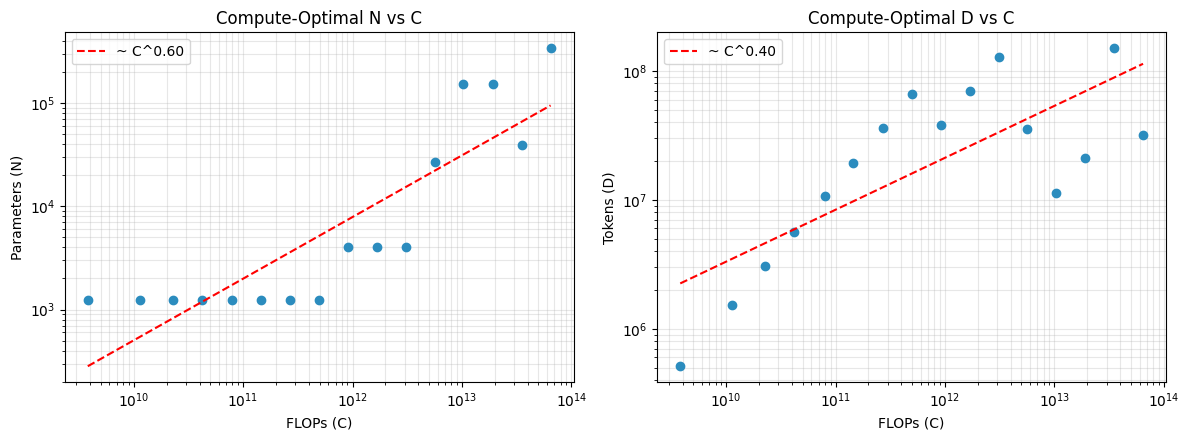

In [32]:
_ = derive_scaling_laws(runs, loss_floor=0.1, C_target=6e23)

## Extensions
Implement MoE models and see how the scaling laws change. Additionally, you can change the learned data distribution. Maybe try adding new forms of arithmetic, or switching to real text data. Note that this will require changing the tokenizer.